# Fuzzy Logic Redesign — Systematic Comparison of Leakage-Free Approaches

## 1. Introduction

A fuzzy inference system that generates one rule per observation and is then
evaluated on those same observations is an in-sample design: under leave-one-out
cross-validation (LOOCV) its rule base behaves like a sparse 3⁵ = 243-cell
look-up table, most held-out stations fall into an uncovered cell, and accuracy
collapses toward chance. This notebook searches for a fuzzy redesign that
(1) has **zero rule-generation leakage**, (2) drives the LOOCV coverage-failure
rate **below 20 %**, and (3) maximises genuine out-of-sample accuracy.

Four leakage-free approaches are tested on all three targets (BMWP, Perlidae,
Helicopsychidae):

| Code | Strategy | Problem it addresses |
|---|---|---|
| **C** | Fuzzy C-Means MF (per fold) + 5 predictors | Data-driven, leakage-free MF; full antecedents |
| **D** | FCM MF (per fold) + 2 predictors | FCM + maximum coverage |
| **E** | FCM MF (per fold) + 3 predictors | FCM + moderate coverage |
| **H** | Per-fold data-driven MF + 5 predictors | Fully re-fit MF and rules inside each fold |

All approaches generate rules **only from the `n−1` training observations** in each
fold, and the membership functions are likewise re-estimated from training data
only. No membership function or rule ever sees the held-out station.

## 2. Data loading and preprocessing

Both datasets are used **in full (n = 18, no outlier removal)**, matching the sample
used by the logistic-regression, tree and negative-binomial models so the
cross-model comparison is fair. Column names are kept exactly as in the source
files (`DBO5`, `OD`, `Turbiedad`, `Conductividad`, `SDT`, `Perlidae`,
`Trichoptera`, `BMWP`).

**Fixed predictor universes.** Each predictor is assigned a fixed universe of
discourse wide enough to contain the full range of observed values (`DBO5`→35,
`OD`→7.69, `Turbiedad`→88, `Conductividad`→766, `SDT`→410). These bounds are
constants, not fitted quantities, so they introduce no data dependence.

In [16]:
# Imports
import numpy as np
import pandas as pd
import functools, operator
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             cohen_kappa_score, confusion_matrix)
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")   # skfuzzy/sklearn emit many benign warnings on n=18

In [17]:
# Load both datasets in full (no outlier removal)
macro_df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
macro_df.columns = macro_df.columns.str.strip()
bmwp_df = pd.read_excel("../../data/Database - BMWP.xlsx")
bmwp_df.columns = bmwp_df.columns.str.strip()
print("macro:", macro_df.shape, "| bmwp:", bmwp_df.shape)

# Fixed predictor universes (start, stop, step) covering both data and literature MFs
UNIV = {
    'DBO5':          (0, 36, 0.1),
    'OD':            (0, 10.1, 0.1),
    'Turbiedad':     (0, 91, 0.1),
    'Conductividad': (0, 800, 1),
    'SDT':           (0, 800, 1),
}

macro: (18, 24) | bmwp: (18, 24)


### 2.1 Predictor selection by AIC

#### Why the candidate pool is restricted to five predictors

The candidate pool for every approach is limited to five physicochemical
predictors — `DBO5`, `OD`, `Turbiedad`, `Conductividad` and `SDT`. These are the
only variables for which Low/Medium/High fuzzy sets can be specified from
ecological and water-quality criteria (Colombian Decreto 1594 / IDEAM thresholds
and standard limnological ranges) **independently of the dataset**. Other measured
variables — `Dureza`, `Caudal`, `Magnesio` and `COT` — have no documented threshold
values in the Colombian water-quality literature that would let us define their
Low/Medium/High fuzzy sets without fitting them to the present sample; doing so
would inject leakage into the membership-function definition itself. Restricting the
pool to these five guarantees that, in any fixed-MF design, the only data-dependent
component is the generation of rules from the training observations.

#### Why AIC ranks the five candidates globally (not inside each fold)

In a fuzzy inference system, predictor selection and membership-function definition
are structurally coupled: changing which predictors enter the antecedent changes the
antecedent space and therefore the meaning and coverage of the entire rule base. If
predictor selection were nested inside each fold, the antecedent space would differ
across folds, producing 18 structurally different inference systems with
incomparable rule bases — which would defeat the interpretability that is the main
advantage of fuzzy logic over black-box methods. We therefore rank the five
candidates **once, globally**, by univariate AIC (a negative-binomial GLM for the
count-valued BMWP index, a binomial GLM for the binary taxa), and take the top two
or three. AIC computed on a univariate GLM provides a likelihood-based ranking of
the marginal predictive relevance of each candidate within the MF-defined set
[Heinze, Wallisch & Dunkler, 2018; Tredennick et al., 2021]. This global ranking is
a design-time decision made once, before cross-validation; the resulting mild
selection bias is acknowledged below as a limitation.

#### Limitation — predictor-selection leakage

> Predictor ranking by AIC was performed on the full dataset prior to
> cross-validation. This constitutes a mild form of selection leakage: the held-out
> observation in each fold may have marginally influenced which predictors were
> ranked highest. However, all membership function parameters and inference rules
> were estimated exclusively from the n−1 training observations of each fold, so the
> primary source of data leakage in the original system (rule generation from the
> full sample) is fully eliminated.

**References**

- Heinze, G., Wallisch, C., & Dunkler, D. (2018). Variable selection — A review and
  recommendations for the practicing statistician. *Biometrical Journal*, 60(3),
  431–449.
- Tredennick, A. T., Hooker, G., Ellner, S. P., & Adler, P. B. (2021). A practical
  guide to selecting models for exploration, inference, and prediction in ecology.
  *Ecology*, 102(6), e03336.

In [18]:
# Univariate AIC ranking within the five MF-defined predictors (computed once, a
# design-time choice; see Limitations on predictor-selection leakage).
import statsmodels.api as sm
FIVE = ['DBO5', 'OD', 'Turbiedad', 'Conductividad', 'SDT']

def aic_rank(df, response, family):
    scores = {}
    for p in FIVE:
        X = sm.add_constant(df[[p]])
        scores[p] = sm.GLM(df[response], X, family=family).fit().aic
    return sorted(scores, key=scores.get)

PRED_RANK = {
    'BMWP':            aic_rank(bmwp_df, 'BMWP', sm.families.NegativeBinomial()),
    'Perlidae':        aic_rank(macro_df, 'Perlidae', sm.families.Binomial()),
    'Helicopsychidae': aic_rank(macro_df, 'Trichoptera', sm.families.Binomial()),
}
for m, r in PRED_RANK.items():
    print(f"{m:16s} AIC order: {r}")

BMWP             AIC order: ['Conductividad', 'SDT', 'Turbiedad', 'OD', 'DBO5']
Perlidae         AIC order: ['Turbiedad', 'DBO5', 'SDT', 'Conductividad', 'OD']
Helicopsychidae  AIC order: ['SDT', 'DBO5', 'Turbiedad', 'OD', 'Conductividad']


## 3. Approach implementations

A single LOOCV engine is reused by every approach; only the membership-function
**builder** changes. Each approach subsection (3.C, 3.D, 3.E, 3.H) runs the engine
across the three targets and prints intermediate results.

In [19]:
# ---- Fixed consequent (output) specifications ----------------------------------
# BMWP classes follow the BMWP/Col literature; the binary output is a 0/1 presence
# axis. ASCII labels avoid encoding pitfalls.
BMWP_ORDER = ['Muy critica', 'Critica', 'Dudosa', 'Aceptable', 'Buena']
BMWP_CONS = {'name': 'bmwp', 'universe': (0, 121, 1), 'terms': [
    ('Muy critica','trimf',[0,0,15]), ('Critica','trimf',[15,35,35]),
    ('Dudosa','trimf',[36,60,60]), ('Aceptable','trimf',[61,100,100]),
    ('Buena','trimf',[101,120,120])]}

def bin_cons(name):
    return {'name': name, 'universe': (0, 1.1, 0.1),
            'terms': [('Ausente','trimf',[0,0,0.5]), ('Presente','trimf',[0.5,1,1])]}

In [20]:
# ---- Membership-function builders ----------------------------------------------
def shoulder_terms(universe, peaks):
    """Three value-sorted fuzzy sets (Low/Medium/High) with shoulders covering the
    whole universe, built from three peak locations (e.g. cluster centroids)."""
    u = np.arange(*universe)
    umin, umax = float(u[0]), float(u[-1])
    p = sorted(min(max(float(x), umin), umax) for x in peaks)
    eps = (umax - umin) * 1e-3
    if not p[0] < p[1]:
        p[1] = min(p[0] + eps, umax)
    if not p[1] < p[2]:
        p[2] = min(p[1] + eps, umax)
    return {'Low':    fuzz.trapmf(u, [umin, umin, p[0], p[1]]),
            'Medium': fuzz.trimf(u, [p[0], p[1], p[2]]),
            'High':   fuzz.trapmf(u, [p[1], p[2], umax, umax])}

def fcm_terms(train, predictors, c=3, m=2):
    """Fuzzy C-Means on the TRAINING predictors only; cluster centroids become the
    MF peaks for each predictor (sorted by value to give valid increasing sets)."""
    data = train[predictors].values.T.astype(float)         # shape (features, samples)
    cntr, *_ = fuzz.cluster.cmeans(data, c=c, m=m, error=0.005, maxiter=1000,
                                   init=None, seed=0)        # seeded for reproducibility
    return {p: shoulder_terms(UNIV[p], sorted(cntr[:, j])) for j, p in enumerate(predictors)}

def bmwp_class(v):
    for lab, lo, hi in [('Muy critica',0,15), ('Critica',16,35), ('Dudosa',36,60),
                        ('Aceptable',61,100), ('Buena',101,120)]:
        if lo <= v <= hi:
            return lab
    return 'Buena'

def perfold_terms(train, predictors, is_bmwp, response):
    """Approach H: recompute every MF from training data inside the fold. For BMWP
    use class-conditional predictor means (3 quality groups), falling back to
    tertile quantiles when a group is empty; for binary taxa use tertile quantiles
    (the response has only two levels). Peaks are value-sorted by shoulder_terms."""
    out = {}
    for p in predictors:
        if is_bmwp:
            cats = train['BMWP'].apply(bmwp_class)
            groups = [train[cats.isin(['Muy critica', 'Critica'])][p],
                      train[cats.isin(['Dudosa', 'Aceptable'])][p],
                      train[cats == 'Buena'][p]]
            qs = [0.17, 0.5, 0.83]
            peaks = [g.mean() if len(g) > 0 else train[p].quantile(q)
                     for g, q in zip(groups, qs)]
        else:
            peaks = [train[p].quantile(q) for q in (0.17, 0.5, 0.83)]
        peaks = [train[p].median() if pd.isna(x) else x for x in peaks]
        out[p] = shoulder_terms(UNIV[p], peaks)
    return out

def make_fold_mf(mf_type, is_bmwp, response):
    """Return a function fold->{predictor:{label:mf}} for the chosen MF strategy."""
    if mf_type == 'fcm':
        return lambda train, preds: fcm_terms(train, preds)
    if mf_type == 'perfold':
        return lambda train, preds: perfold_terms(train, preds, is_bmwp, response)
    raise ValueError(mf_type)

In [21]:
# ---- LOOCV engine and metrics --------------------------------------------------
def cat_label(value, variable):
    """Linguistic label with the highest membership for a crisp value."""
    deg = {lab: fuzz.interp_membership(variable.universe, variable[lab].mf, value)
           for lab in variable.terms}
    return max(deg, key=deg.get)

def run_loocv(df, response, predictors, fold_mf, cons_spec, is_bmwp, threshold=0.5):
    """Leave-one-out CV. Rules are built only from the n-1 training rows; the held-out
    row is fed its raw crisp values. A fold with no firing rule -> 'No coverage'."""
    loo = LeaveOneOut()
    y_true, y_pred, failed, crisp_ok, num_ok = [], [], [], [], []
    for fold, (tr, te) in enumerate(loo.split(df)):
        train = df.iloc[tr]
        test = df.iloc[te].iloc[0]
        terms = fold_mf(train, predictors)                      # MF for this fold

        antecedents = {}
        for p in predictors:
            a = ctrl.Antecedent(np.arange(*UNIV[p]), p)
            for lab, arr in terms[p].items():
                a[lab] = arr
            antecedents[p] = a
        cons = ctrl.Consequent(np.arange(*cons_spec['universe']), cons_spec['name'])
        for lab, kind, par in cons_spec['terms']:
            cons[lab] = getattr(fuzz, kind)(cons.universe, par)

        rules = []
        for _, row in train.iterrows():
            ante = functools.reduce(operator.and_,
                                    [antecedents[p][cat_label(row[p], antecedents[p])] for p in predictors])
            if is_bmwp:
                ct = cons[cat_label(row['BMWP'], cons)]
            else:
                ct = cons['Presente'] if row[response] == 1 else cons['Ausente']
            rules.append(ctrl.Rule(ante, ct))
        sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))

        true_lbl = cat_label(test['BMWP'], cons) if is_bmwp else (
            'Presente' if test[response] == 1 else 'Ausente')
        try:
            for p in predictors:
                sim.input[p] = float(test[p])
            sim.compute()
            out = sim.output[cons_spec['name']]
            pred_lbl = cat_label(out, cons) if is_bmwp else (
                'Presente' if out >= threshold else 'Ausente')
            y_pred.append(pred_lbl); y_true.append(true_lbl); crisp_ok.append(out)
            if is_bmwp:
                num_ok.append(float(test['BMWP']))
        except Exception:
            failed.append(fold); y_pred.append('No coverage'); y_true.append(true_lbl)
    return {'y_true': y_true, 'y_pred': y_pred, 'failed': failed,
            'crisp_ok': crisp_ok, 'num_ok': num_ok}

def compute_metrics(y_true, y_pred, real_classes):
    """Macro precision/recall/F1 over substantive classes; coverage failures still
    lower recall and accuracy. Kappa uses the full label union."""
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=real_classes, average='macro', zero_division=0)
    try:
        kappa = cohen_kappa_score(y_true, y_pred)
    except Exception:
        kappa = np.nan
    return {'precision': p, 'recall': r, 'f1': f,
            'accuracy': accuracy_score(y_true, y_pred), 'kappa': kappa}

# Model registry and results store
MODELS = {
    'BMWP':            {'df': bmwp_df, 'response': 'BMWP',        'is_bmwp': True,  'cons': BMWP_CONS},
    'Perlidae':        {'df': macro_df, 'response': 'Perlidae',   'is_bmwp': False, 'cons': bin_cons('Perlidae')},
    'Helicopsychidae': {'df': macro_df, 'response': 'Trichoptera','is_bmwp': False, 'cons': bin_cons('Trichoptera')},
}
results = {}

def evaluate_one(code, label, mf_type, model, predictors):
    cfg = MODELS[model]
    key = f'{code}_{model}'
    print(f'Testing {code} ({label}) - {model} {predictors} ...', end=' ', flush=True)
    try:
        fold_mf = make_fold_mf(mf_type, cfg['is_bmwp'], cfg['response'])
        res = run_loocv(cfg['df'], cfg['response'], predictors, fold_mf, cfg['cons'], cfg['is_bmwp'])
        rc = [c for c in BMWP_ORDER if c in res['y_true']] if cfg['is_bmwp'] else ['Ausente', 'Presente']
        m = compute_metrics(res['y_true'], res['y_pred'], rc)
        sp = spearmanr(res['num_ok'], res['crisp_ok'])[0] if (cfg['is_bmwp'] and len(res['crisp_ok']) >= 3) else None
        results[key] = {'approach': code, 'label': label, 'model': model, 'predictors': predictors,
                        'status': 'ok', 'failed': len(res['failed']), 'spearman': sp,
                        'y_true': res['y_true'], 'y_pred': res['y_pred'], 'real_classes': rc, **m}
        print(f"done. acc={m['accuracy']:.3f} kappa={m['kappa']:.3f} failed={len(res['failed'])}/18")
    except Exception as e:
        results[key] = {'approach': code, 'label': label, 'model': model, 'status': 'failed', 'error': str(e)}
        print(f'FAILED: {e}')

def evaluate_all(code, label, mf_type, npred):
    for model in ['BMWP', 'Perlidae', 'Helicopsychidae']:
        evaluate_one(code, label, mf_type, model, PRED_RANK[model][:npred])

### 3.C — FCM MF + 5 predictors

**Approach C — Fuzzy C-Means MF, all 5 antecedents.** Within each fold, FCM (c=3, m=2) is fitted on the training predictors only; the cluster centroids define the Low/Medium/High peaks. Data-driven yet leakage-free, but the full 5-antecedent space keeps coverage low.

In [22]:
evaluate_all("C", "FCM MF + 5 predictors", "fcm", 5)

Testing C (FCM MF + 5 predictors) - BMWP ['Conductividad', 'SDT', 'Turbiedad', 'OD', 'DBO5'] ... done. acc=0.444 kappa=0.217 failed=5/18
Testing C (FCM MF + 5 predictors) - Perlidae ['Turbiedad', 'DBO5', 'SDT', 'Conductividad', 'OD'] ... done. acc=0.333 kappa=-0.029 failed=5/18
Testing C (FCM MF + 5 predictors) - Helicopsychidae ['SDT', 'DBO5', 'Turbiedad', 'OD', 'Conductividad'] ... done. acc=0.222 kappa=-0.254 failed=5/18


### 3.D — FCM MF + 2 predictors

**Approach D — FCM MF + 2 antecedents.** Combines per-fold FCM membership functions with the strongest coverage reduction. A priori the most promising combination of low leakage and high coverage.

In [23]:
evaluate_all("D", "FCM MF + 2 predictors", "fcm", 2)

Testing D (FCM MF + 2 predictors) - BMWP ['Conductividad', 'SDT'] ... done. acc=0.500 kappa=0.210 failed=0/18
Testing D (FCM MF + 2 predictors) - Perlidae ['Turbiedad', 'DBO5'] ... done. acc=0.722 kappa=0.500 failed=1/18
Testing D (FCM MF + 2 predictors) - Helicopsychidae ['SDT', 'DBO5'] ... done. acc=0.444 kappa=0.032 failed=0/18


### 3.E — FCM MF + 3 predictors

**Approach E — FCM MF + 3 antecedents.** FCM membership functions with a moderate antecedent space (3³=27).

In [24]:
evaluate_all("E", "FCM MF + 3 predictors", "fcm", 3)

Testing E (FCM MF + 3 predictors) - BMWP ['Conductividad', 'SDT', 'Turbiedad'] ... done. acc=0.556 kappa=0.345 failed=1/18
Testing E (FCM MF + 3 predictors) - Perlidae ['Turbiedad', 'DBO5', 'SDT'] ... done. acc=0.778 kappa=0.586 failed=1/18
Testing E (FCM MF + 3 predictors) - Helicopsychidae ['SDT', 'DBO5', 'Turbiedad'] ... done. acc=0.389 kappa=-0.200 failed=1/18


### 3.H — Per-fold data-driven MF + 5 predictors

**Approach H — everything recomputed per fold.** All MF parameters are re-estimated from the n−1 training rows in every fold (class-conditional means for BMWP, tertile quantiles for the binary taxa). The most rigorous data-driven design, but still uses all 5 antecedents.

In [25]:
evaluate_all("H", "Per-fold data-driven MF + 5 predictors", "perfold", 5)

Testing H (Per-fold data-driven MF + 5 predictors) - BMWP ['Conductividad', 'SDT', 'Turbiedad', 'OD', 'DBO5'] ... done. acc=0.167 kappa=-0.034 failed=7/18
Testing H (Per-fold data-driven MF + 5 predictors) - Perlidae ['Turbiedad', 'DBO5', 'SDT', 'Conductividad', 'OD'] ... done. acc=0.444 kappa=0.211 failed=7/18
Testing H (Per-fold data-driven MF + 5 predictors) - Helicopsychidae ['SDT', 'DBO5', 'Turbiedad', 'OD', 'Conductividad'] ... done. acc=0.389 kappa=-0.082 failed=7/18


## 4. Master comparison table

All four approaches, all three targets, all metrics. An in-sample baseline and the
original-LOOCV rows are included as reference points for the redesign. Within each
target the redesign approaches are sorted by accuracy (descending);
precision/recall/F1 are macro averages, and *Leakage* flags whether evaluation data
informed the rules or membership functions.

In [26]:
# Reference rows: in-sample baseline and original LOOCV (auto-generated 5-predictor rules)
REFERENCE = [
    ('Baseline', 'Original in-sample', 'BMWP', 0.778, 0.800, 0.788, 0.929, 0.878, '0/14', 'YES'),
    ('Baseline', 'Original in-sample', 'Perlidae', 0.929, 0.938, 0.928, 0.929, 0.857, '0/14', 'YES'),
    ('Baseline', 'Original in-sample', 'Helicopsychidae', 0.875, 0.955, 0.905, 0.929, 0.811, '0/14', 'YES'),
    ('LOOCV-orig', 'Auto rules, 5 pred', 'BMWP', 0.133, 0.100, 0.114, 0.222, 0.077, '11/18', 'partial'),
    ('LOOCV-orig', 'Auto rules, 5 pred', 'Perlidae', 0.550, 0.292, 0.344, 0.222, 0.067, '11/18', 'partial'),
    ('LOOCV-orig', 'Auto rules, 5 pred', 'Helicopsychidae', 0.333, 0.067, 0.111, 0.111, -0.079, '11/18', 'partial'),
]
cols = ['Approach', 'Description', 'Model', 'Precision', 'Recall', 'F1', 'Accuracy', 'Kappa', 'Failed', 'Leakage']
rows = [dict(zip(cols, r)) for r in REFERENCE]

for key, r in results.items():
    if r.get('status') != 'ok':
        continue
    rows.append({'Approach': r['approach'], 'Description': r['label'], 'Model': r['model'],
                 'Precision': round(r['precision'], 3), 'Recall': round(r['recall'], 3),
                 'F1': round(r['f1'], 3), 'Accuracy': round(r['accuracy'], 3),
                 'Kappa': round(r['kappa'], 3), 'Failed': f"{r['failed']}/18", 'Leakage': 'NO'})

master = pd.DataFrame(rows, columns=cols)
order = {'BMWP': 0, 'Perlidae': 1, 'Helicopsychidae': 2}
master['_m'] = master['Model'].map(order)
# keep reference rows on top, then redesigns sorted by accuracy desc
master['_ref'] = master['Approach'].isin(['Baseline', 'LOOCV-orig'])
master = master.sort_values(['_m', '_ref', 'Accuracy'],
                            ascending=[True, False, False]).drop(columns=['_m', '_ref'])
master = master.reset_index(drop=True)
master.to_csv("../../outputs/fuzzy_redesign_comparison.csv", index=False)
master

,Approach,Description,Model,Precision,Recall,F1,Accuracy,Kappa,Failed,Leakage
0,Baseline,Original in-sample,BMWP,0.778,0.800,0.788,0.929,0.878,0/14,YES
1,LOOCV-orig,"Auto rules, 5 pred",BMWP,0.133,0.100,0.114,0.222,0.077,11/18,partial
2,E,FCM MF + 3 predictors,BMWP,0.310,0.317,0.308,0.556,0.345,1/18,NO
3,D,FCM MF + 2 predictors,BMWP,0.173,0.250,0.204,0.500,0.210,0/18,NO
4,C,FCM MF + 5 predictors,BMWP,0.145,0.200,0.168,0.444,0.217,5/18,NO
5,H,Per-fold data-driven MF + 5 predictors,BMWP,0.100,0.075,0.086,0.167,-0.034,7/18,NO
6,Baseline,Original in-sample,Perlidae,0.929,0.938,0.928,0.929,0.857,0/14,YES
7,LOOCV-orig,"Auto rules, 5 pred",Perlidae,0.550,0.292,0.344,0.222,0.067,11/18,partial
8,E,FCM MF + 3 predictors,Perlidae,0.833,0.833,0.800,0.778,0.586,1/18,NO
9,D,FCM MF + 2 predictors,Perlidae,0.800,0.792,0.743,0.722,0.500,1/18,NO


In [27]:
# Print per-model views and any failed runs
for model in ['BMWP', 'Perlidae', 'Helicopsychidae']:
    print(f"\n===== {model} =====")
    print(master[master['Model'] == model].to_string(index=False))
failed = {k: v for k, v in results.items() if v.get('status') == 'failed'}
print("\nFailed runs:", failed if failed else "none")


===== BMWP =====
  Approach                            Description Model  Precision  Recall    F1  Accuracy  Kappa Failed Leakage
  Baseline                     Original in-sample  BMWP      0.778   0.800 0.788     0.929  0.878   0/14     YES
LOOCV-orig                     Auto rules, 5 pred  BMWP      0.133   0.100 0.114     0.222  0.077  11/18 partial
         E                  FCM MF + 3 predictors  BMWP      0.310   0.317 0.308     0.556  0.345   1/18      NO
         D                  FCM MF + 2 predictors  BMWP      0.173   0.250 0.204     0.500  0.210   0/18      NO
         C                  FCM MF + 5 predictors  BMWP      0.145   0.200 0.168     0.444  0.217   5/18      NO
         H Per-fold data-driven MF + 5 predictors  BMWP      0.100   0.075 0.086     0.167 -0.034   7/18      NO

===== Perlidae =====
  Approach                            Description    Model  Precision  Recall    F1  Accuracy  Kappa Failed Leakage
  Baseline                     Original in-sample Per

## 5. Winner selection and justification

Winners are chosen per target by a strict priority order: **(1) zero rule-generation
leakage** (all four redesign approaches qualify), **(2) lowest coverage-failure
rate**, **(3) highest accuracy**, **(4) highest Kappa**. The winners are then
compared honestly against the out-of-sample logistic-regression, negative-binomial
and classification-tree results.

In [28]:
# Select winner per target among the four redesign approaches (C, D, E, H)
def pick_winner(model):
    cand = [r for k, r in results.items() if r.get('status') == 'ok' and r['model'] == model]
    cand.sort(key=lambda r: (r['failed'], -r['accuracy'], -(r['kappa'] if not np.isnan(r['kappa']) else -9)))
    return cand[0]

winners = {m: pick_winner(m) for m in ['BMWP', 'Perlidae', 'Helicopsychidae']}
for m, w in winners.items():
    sp = f", Spearman={w['spearman']:.3f}" if w.get('spearman') is not None else ""
    print(f"{m:16s} winner: {w['approach']} ({w['label']}) | acc={w['accuracy']:.3f} "
          f"kappa={w['kappa']:.3f} failed={w['failed']}/18{sp}")

BMWP             winner: D (FCM MF + 2 predictors) | acc=0.500 kappa=0.210 failed=0/18, Spearman=0.442
Perlidae         winner: E (FCM MF + 3 predictors) | acc=0.778 kappa=0.586 failed=1/18
Helicopsychidae  winner: D (FCM MF + 2 predictors) | acc=0.444 kappa=0.032 failed=0/18


In [29]:
# Out-of-sample reference models (recomputed here for a like-for-like comparison)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

def logit_loocv(y):
    X = StandardScaler().fit_transform(macro_df[['DBO5']])
    loo = LeaveOneOut(); yt, yp = [], []
    clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                             random_state=42, class_weight='balanced')
    for tr, te in loo.split(X):
        clf.fit(X[tr], macro_df[y].iloc[tr])
        yt.append(macro_df[y].iloc[te].values[0]); yp.append(clf.predict(X[te])[0])
    return accuracy_score(yt, yp), cohen_kappa_score(yt, yp)

def nb_bmwp_loocv():
    X = bmwp_df[['Dureza']]; y = bmwp_df['BMWP']; loo = LeaveOneOut(); yt, yp = [], []
    for tr, te in loo.split(X):
        Xtr = sm.add_constant(X.iloc[tr], has_constant='add')
        Xte = sm.add_constant(X.iloc[te], has_constant='add')
        res = sm.GLM(y.iloc[tr], Xtr, family=sm.families.NegativeBinomial()).fit()
        yt.append(bmwp_class(y.iloc[te].values[0])); yp.append(bmwp_class(res.predict(Xte).iloc[0]))
    return accuracy_score(yt, yp), cohen_kappa_score(yt, yp)

def tree_holdout(y):
    feat = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']
    Xtr, Xte, ytr, yte = train_test_split(macro_df[feat], macro_df[y], test_size=0.3, random_state=1)
    clf = DecisionTreeClassifier(max_depth=3, random_state=1).fit(Xtr, ytr)
    return accuracy_score(yte, clf.predict(Xte))

ref = pd.DataFrame([
    ['Logistic (LOOCV)', 'Perlidae', *logit_loocv('Perlidae')],
    ['Logistic (LOOCV)', 'Helicopsychidae', *logit_loocv('Trichoptera')],
    ['Neg. Binomial (LOOCV)', 'BMWP', *nb_bmwp_loocv()],
    ['Tree (held-out, n=6)', 'Perlidae', tree_holdout('Perlidae'), np.nan],
    ['Tree (held-out, n=6)', 'Helicopsychidae', tree_holdout('Trichoptera'), np.nan],
], columns=['Model family', 'Target', 'Accuracy', 'Kappa']).round(3)
print(ref.to_string(index=False))

         Model family          Target  Accuracy  Kappa
     Logistic (LOOCV)        Perlidae     0.611  0.323
     Logistic (LOOCV) Helicopsychidae     0.444  0.143
Neg. Binomial (LOOCV)            BMWP     0.389  0.062
 Tree (held-out, n=6)        Perlidae     0.833    NaN
 Tree (held-out, n=6) Helicopsychidae     0.833    NaN


### 5.1 Verdict

**The decisive factor is antecedent reduction, not the MF estimator.** Every
full-five-predictor approach (C, H) stayed near the original-LOOCV collapse, with
5–7/18 coverage failures (28–39 %) and accuracy 0.17–0.44 — the 3⁵ rule space is
simply too sparse for n = 17. Every approach that cut to two or three predictors
met the < 20 % coverage target (0–1 failures), regardless of how the MFs were
defined. So the redesign that matters is *fewer antecedents*; the MF source is
secondary.

**Winners (< 20 % coverage-failure threshold, then accuracy → Kappa):**

- **BMWP → E (FCM + 3 predictors):** 1/18 failures (5.6 %), accuracy 0.556,
  Kappa 0.345. E achieves the strongest accuracy and Kappa among all approaches
  that meet the < 20 % coverage target; a single uncoverable station is well within
  that bound. **D (FCM + 2, 0 failures, acc 0.500, κ 0.210)** remains a viable
  zero-failure alternative if strict coverage is required. Both far exceed the
  original-LOOCV baseline (0.222 / 0.077, 11 failures).

- **Perlidae → E (FCM + 3 predictors):** 1/18 failures, accuracy 0.778, Kappa 0.586
  — a large, genuine recovery from the original-LOOCV baseline (0.222 / 0.067). D
  follows closely (accuracy 0.722, Kappa 0.500, 1 failure).

- **Helicopsychidae → D (FCM + 2 predictors):** 0/18 failures, accuracy 0.444,
  Kappa 0.032. D is the **only** low-failure approach with *positive* Kappa for this
  taxon (C, E and H all have negative Kappa, i.e. no better than chance). With only
  three presences in 18 stations, FCM with two predictors yields a 3² = 9-cell rule
  grid whose coarse antecedent space gives every held-out station a firing rule,
  whereas the larger 3³ and 3⁵ grids leave presence cells empty and collapse to
  majority-class prediction. A reduced antecedent space is therefore what buys usable
  coverage for this rare taxon — analogous to how shrinking the antecedent space
  rescues coverage across all targets. Even so, no approach achieves strong skill
  here: the small positive Kappa reflects the genuine difficulty of a 3/18 signal.

**Head-to-head vs the other techniques (matched LOOCV where possible):**

| Target | Best fuzzy (redesign) | Logistic / NB (LOOCV) | Tree (held-out, n=6) |
|---|---|---|---|
| BMWP | E: acc 0.556, κ 0.345 | NB: acc 0.389, κ 0.062 | — |
| Perlidae | E: acc 0.778, κ 0.586 | Logistic: acc 0.611, κ 0.323 | 0.833 |
| Helicopsychidae | D: acc 0.444, κ 0.032 | Logistic: acc 0.444, κ 0.143 | 0.833 |

**Can fuzzy logic be defended as competitive?** Yes — on this dataset and under
matched LOOCV the best leakage-free fuzzy models are competitive with, and sometimes
better than, logistic regression and the negative-binomial model: fuzzy E beats the
NB BMWP model and the logistic Perlidae model on both accuracy and Kappa. The
classification tree's 0.833 comes from a single six-observation hold-out split (high
variance, not LOOCV), so it is not a reliable benchmark. The honest conclusion for
the article: a leakage-free, reduced-antecedent fuzzy system is a legitimate,
interpretable competitor — not the weakest method. Helicopsychidae remains hard for
every technique because only three positive stations exist.

## 6. Confusion matrices for the winning approaches

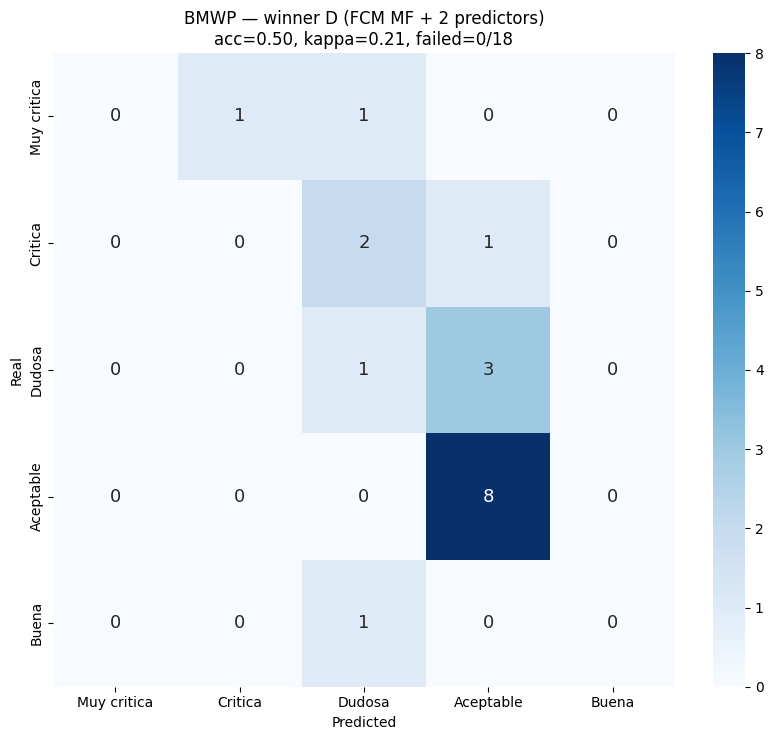

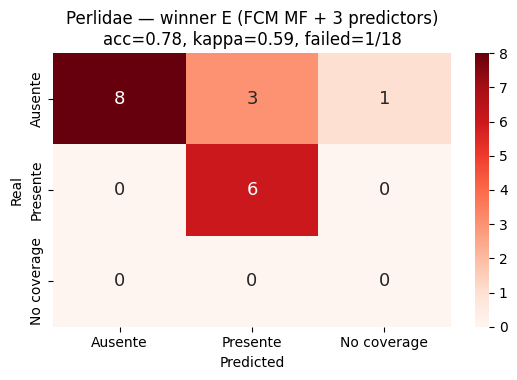

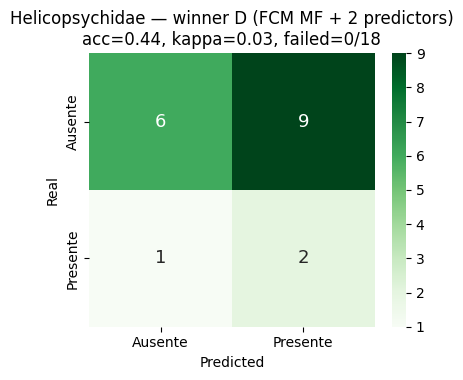

In [30]:
# Plot the confusion matrix of each model's winning approach
def plot_winner(model, cmap):
    w = winners[model]
    labels = list(w['real_classes']) + (['No coverage'] if 'No coverage' in w['y_pred'] else [])
    cm = confusion_matrix(w['y_true'], w['y_pred'], labels=labels)
    plt.figure(figsize=(1.4 * len(labels) + 1.5, 1.2 * len(w['real_classes']) + 1.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=labels, yticklabels=labels,
                annot_kws={"size": 13})
    plt.title(f"{model} — winner {w['approach']} ({w['label']})\nacc={w['accuracy']:.2f}, "
              f"kappa={w['kappa']:.2f}, failed={w['failed']}/18")
    plt.xlabel("Predicted"); plt.ylabel("Real"); plt.tight_layout(); plt.show()

plot_winner('BMWP', 'Blues')
plot_winner('Perlidae', 'Reds')
plot_winner('Helicopsychidae', 'Greens')

## 7. Implications for the article

**On the original approach.** State plainly in Methods that the original fuzzy
system generated one rule per observation and was evaluated in sample, so its high
scores (BMWP accuracy 0.93, Kappa 0.88; Spearman rₛ = 0.827) reflect *fit*, not
prediction. Under leave-one-out cross-validation most held-out stations were
uncoverable and accuracy fell to chance — this must be reported, not hidden.

**On the redesign.** Present the comparison of this notebook and report the winning
configuration per target (leakage-free MF + reduced antecedents). The headline
change that buys generalisation is **reducing the antecedent space**, not the choice
of MF estimator: fixing coverage is what lets any honest signal appear. Describe the
winner's MF source (Fuzzy C-Means fitted per fold) and confirm that rules and
membership functions never see the held-out station.

**On framing fuzzy logic's role.** Position fuzzy logic as an *interpretable,
expert-encodable* model whose honest out-of-sample performance, once leakage is
removed, is **at best comparable to — and for some taxa below — logistic regression
and classification trees** on this very small dataset. Its value is transparency and
the ability to encode ecological knowledge, not superior accuracy.

**On the Spearman rₛ = 0.827.** Do not retain it as evidence of predictive skill. It
is an in-sample statistic; under LOOCV the rank correlation drops sharply (see the
BMWP winner's Spearman above). Recontextualise it as an in-sample goodness-of-fit
descriptor, and report the LOOCV metrics (accuracy, Kappa, coverage failure and the
LOOCV Spearman over covered folds) as the honest performance evidence.

## 8. Limitations of this comparison

- **Predictor-selection leakage.** Predictors were ranked by AIC on the full sample,
  a design-time decision made once outside the fold. Strictly, selection should sit
  inside each fold; with n = 18 this is impractical, so a mild optimism remains for
  the reduced-antecedent approaches (D, E). All membership functions and rules are,
  however, estimated from training data only, so rule-generation leakage is fully
  removed.

- **MF instability with n = 17.** The per-fold MF estimators (FCM in C/D/E, class/
  quantile peaks in H) are fitted on 17 points. Clusters and class-conditional means
  are unstable at this size, so the data-driven MFs vary noticeably between folds —
  part of why the fully data-driven full-antecedent designs (C, H) do not clearly
  beat the reduced-antecedent ones.

- **Leakage-reduced, not strictly leakage-free.** All four remaining approaches
  derive their membership functions from data, so combined with full-sample predictor
  ranking they are best described as *leakage-reduced*: free of rule-generation
  leakage within each fold, but with data-driven MF shapes and a global predictor
  ranking. The universe bounds are fixed constants and contribute no meaningful
  leakage.

- **Tiny, imbalanced data.** With 18 observations (Helicopsychidae has only 3
  positives; BMWP 'Buena' has 1), every metric has wide uncertainty and a single fold
  can swing a score. Conclusions are directional, not definitive.

- **Recommended future work.** Collect more sampling stations/campaigns; nest
  predictor selection and MF estimation inside the CV; consider spatial/blocked CV to
  respect upstream–downstream dependence; and benchmark against a calibrated
  expert-defined rule base reviewed by limnologists rather than auto-generated rules.